# 📘 Week 2 Assignment — Classical ML 

This notebook performs a complete Classical Machine Learning pipeline on the Tesla Deliveries & Production dataset (2015–2025).

## Part 1 - Setting Environments and Collecting Data

Installs the required Python libraries and downloads the Tesla deliveries dataset from Kaggle using the kagglehub library.

### 1.1 Installing Libraries

In [87]:
# %pip install  numpy  pandas  matplotlib seaborn scipy scikit-learn kagglehub 

### 1.2 Downloading Dataset from kaggle

In [88]:
import kagglehub
import shutil

path = kagglehub.dataset_download("nalisha/tesla-ea-deliveries-and-production-data20152025")

shutil.copytree(
    path,
    ".",
    dirs_exist_ok=True
)

print("Dataset Downloaded ! ")

Dataset Downloaded ! 


## Part 2 - Dataset loading 

Loads the CSV file into a pandas DataFrame, inspects its shape, data types, and summary statistics.

### 2.1 Loading Dataset

In [89]:
import pandas as pd 

df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print("Dataset Loaded !")

Dataset Loaded !


In [90]:
print("First 10 data in dataset:")
df.head(10)


First 10 data in dataset:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216
8,2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.00,Interpolated (Month),13264
9,2021,3,Middle East,Model Y,7790,8208,50591.60,82,485,566.72,Interpolated (Month),3383


### 2.2 Dataset understanding

In [91]:
print(f"Dataset Shape : {df.shape}")

Dataset Shape : (2640, 12)


In [92]:
print(f"columns in dataset: {df.columns.tolist()} ")

columns in dataset: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'] 


In [93]:
print(f"Data types in datatset : \n{df.dtypes}")

Data types in datatset : 
Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object


In [94]:
print(f"Describe : ")
df.describe()

Describe : 


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## Part 3 - Dataset cleaning

Checks for missing values and duplicate rows, then removes the Source_Type column because it only contains metadata.

### 3.1 Handeling missing values 

In [95]:
print("Missing Values :")
df.isnull().sum()

Missing Values :


Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

### 3.2 Handeling duplicate values

In [96]:
print("Duplicate rows :")
df.duplicated().sum()

Duplicate rows :


np.int64(0)

### 3.3 Dropping Source Type - metadata about data collection

In [97]:
df.drop(columns=['Source_Type'],inplace=True)

## Part 4 - Exploratory Data Analysis

Explores the dataset through visualizations and Outliers are identified using the IQR method.

In [98]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = (10,8)

### 4.1 Dataset Visualization

Text(0.5, 1.0, 'Average Deliveries by Model')

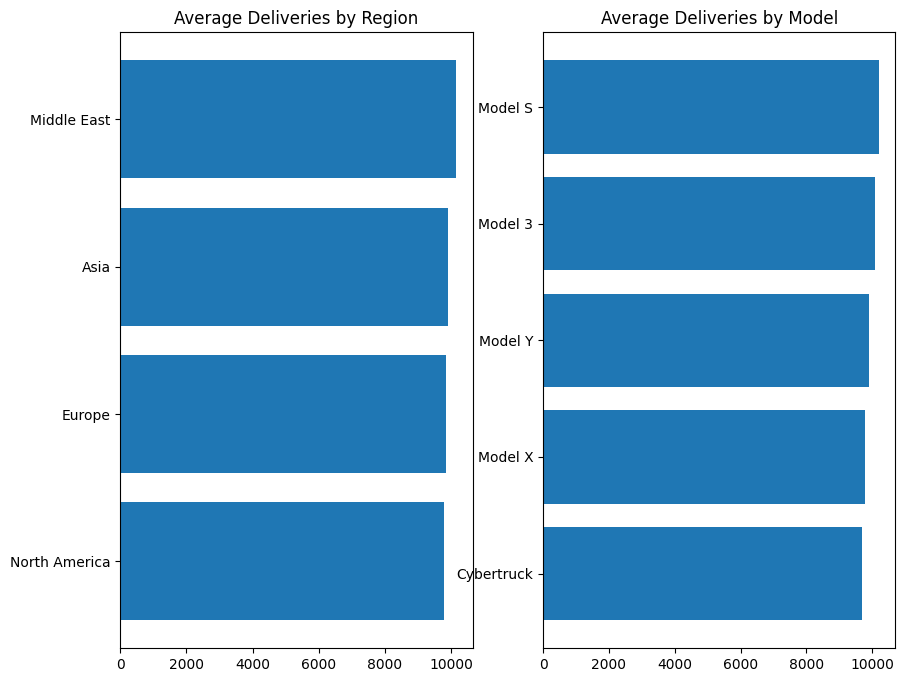

In [99]:
# Average Deliveries by Region and Model

fig , axes = plt.subplots(1,2)

region_avg = df.groupby('Region')['Estimated_Deliveries'].mean().sort_values()
axes[0].barh(region_avg.index,region_avg.values)
axes[0].set_title('Average Deliveries by Region')

model_avg = df.groupby('Model')['Estimated_Deliveries'].mean().sort_values()
axes[1].barh(model_avg.index , model_avg.values)
axes[1].set_title('Average Deliveries by Model')


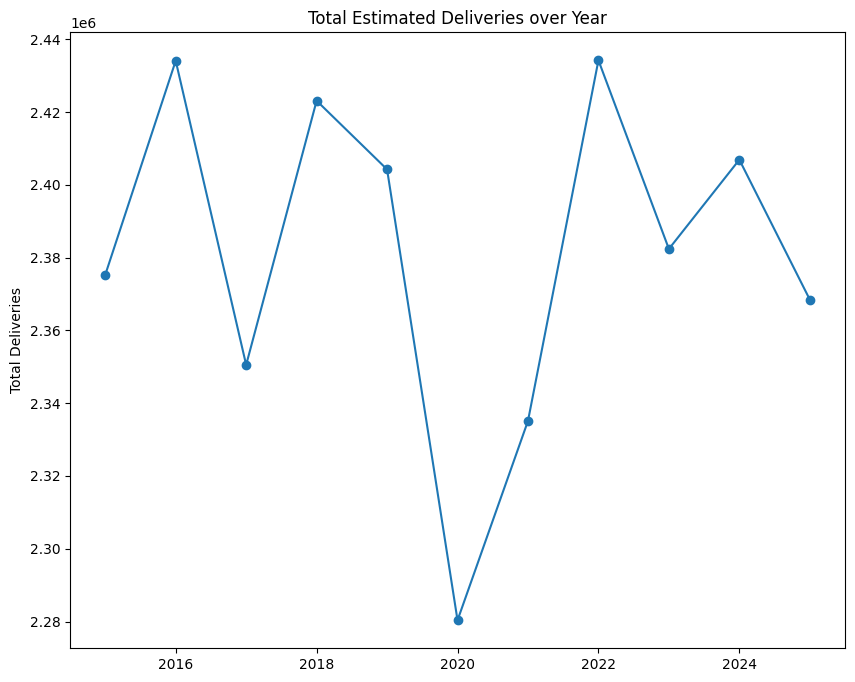

In [100]:
# Time Trends
# Delivery over years

yearly = df.groupby('Year')['Estimated_Deliveries'].sum()
plt.plot(yearly , marker ='o')
plt.title('Total Estimated Deliveries over Year')
plt.ylabel('Total Deliveries')
plt.show()

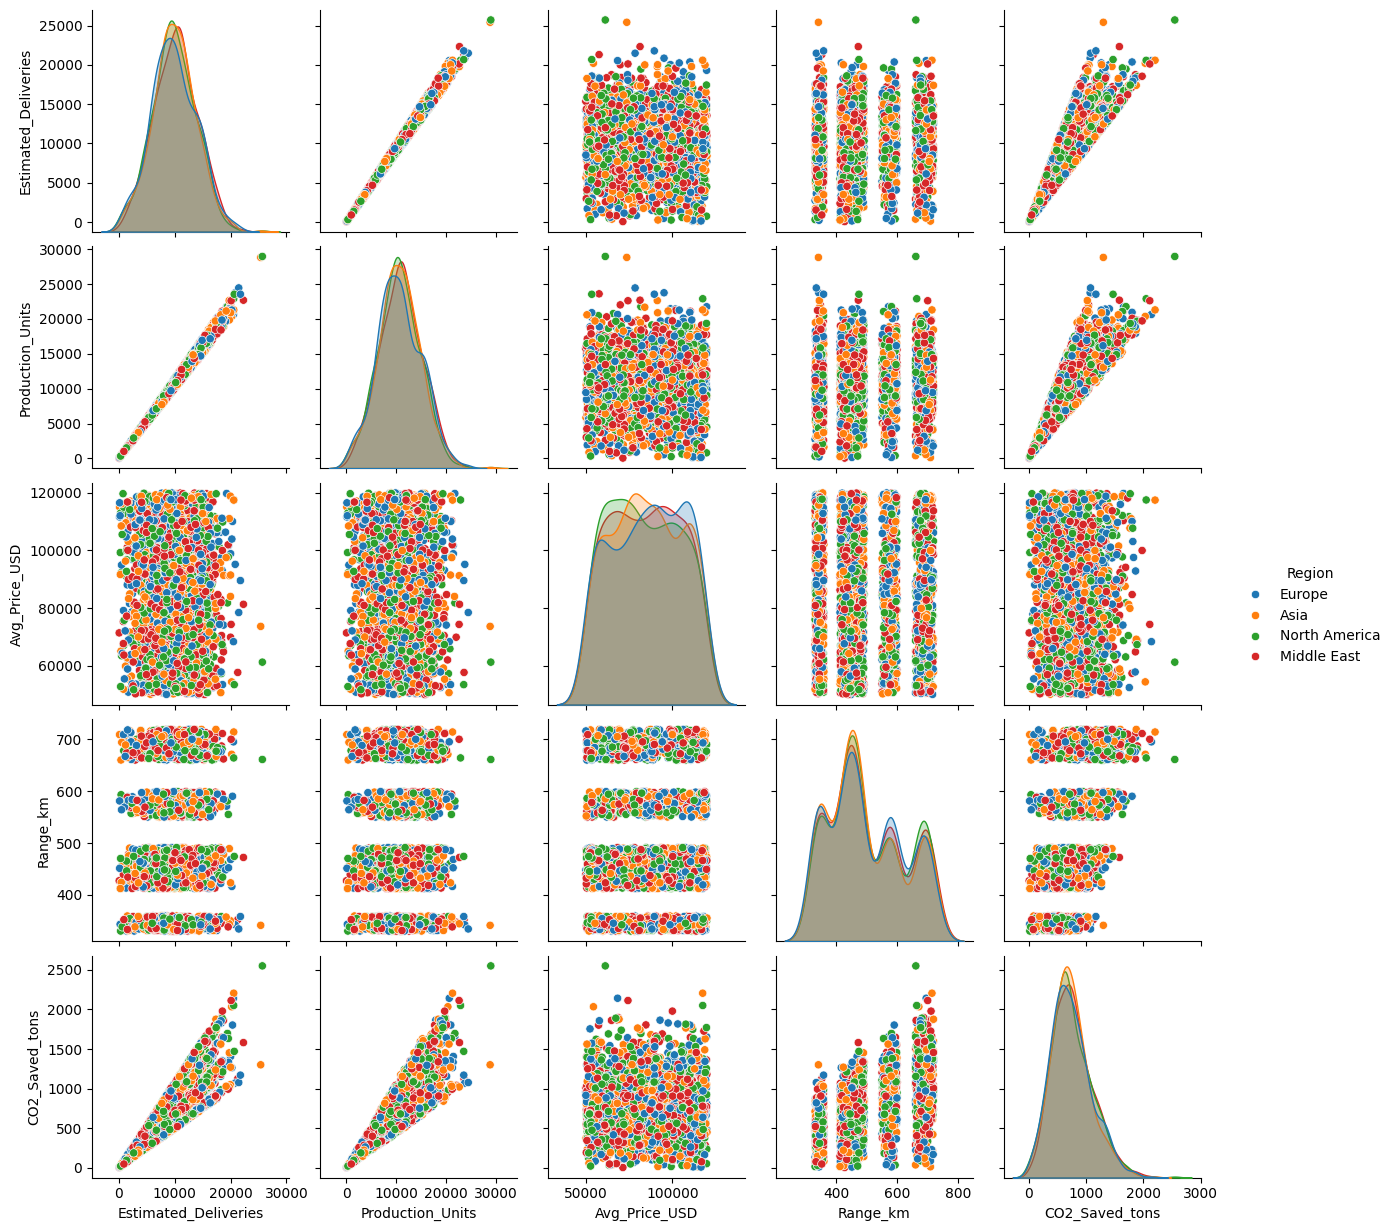

In [101]:
# Pairplot of key variable

sns.pairplot(df[['Estimated_Deliveries', 'Production_Units',
                 'Avg_Price_USD', 'Range_km', 'CO2_Saved_tons', 'Region']],
             hue='Region', diag_kind='kde')
plt.show()

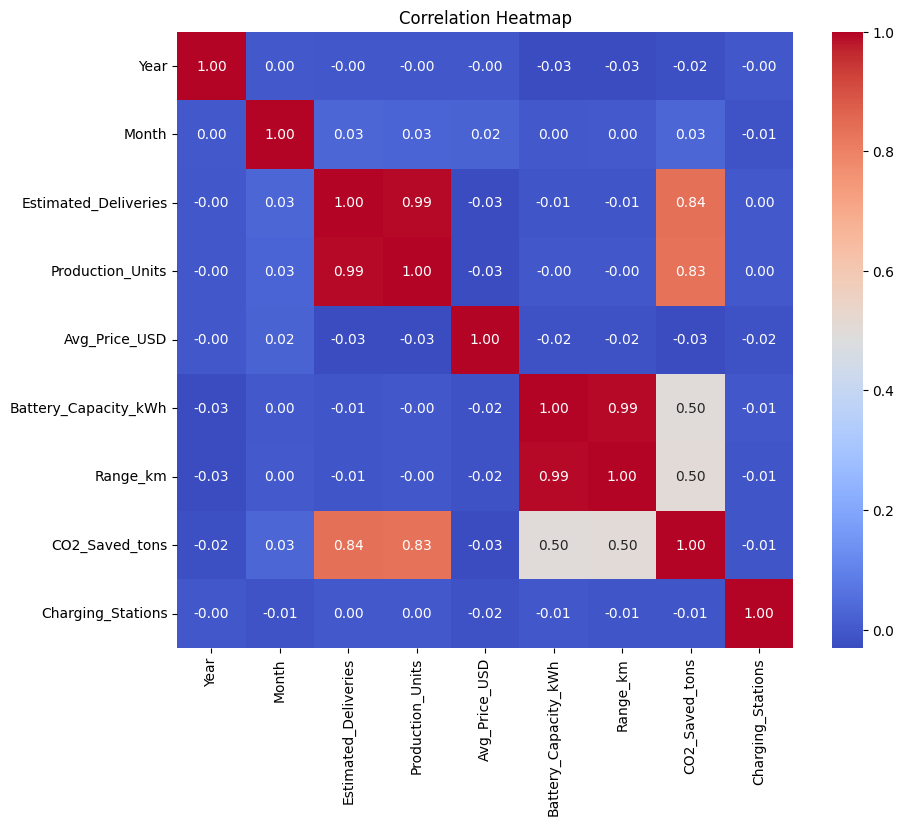

In [102]:
# Correlation heatmap 
numeric_col = df.select_dtypes(include=np.number).columns
corr = df[numeric_col].corr()

sns.heatmap(corr , annot=True , fmt='.2f' ,cmap='coolwarm' , square=True )
plt.title("Correlation Heatmap")
plt.show()


##  Explanation from Correlation Heatmap

### 4.2 Outlier Detection

Text(0.5, 1.0, 'CO2 saved')

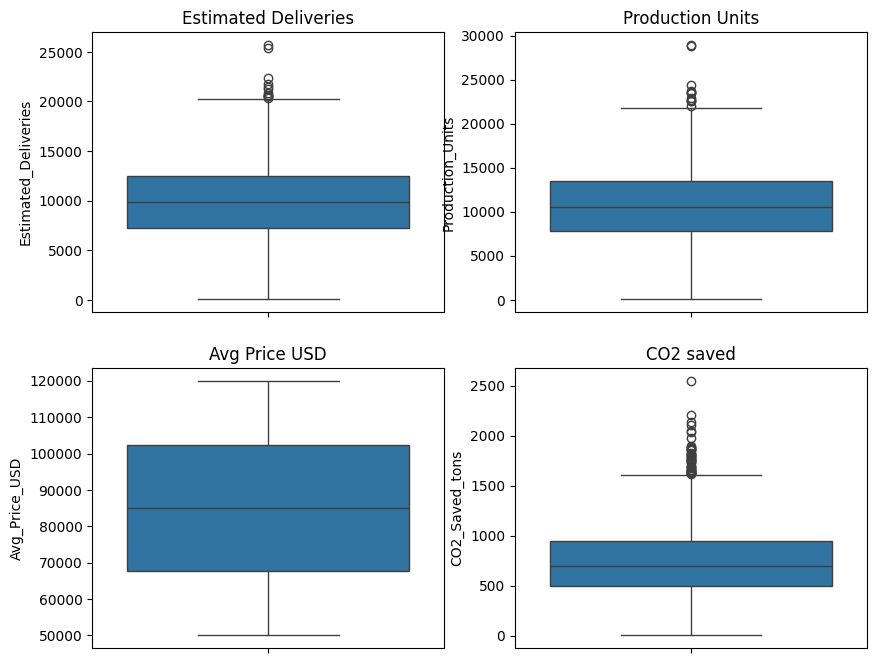

In [103]:
fig , axes = plt.subplots(2,2)

sns.boxplot(y=df['Estimated_Deliveries'] , ax=axes[0,0])
axes[0,0].set_title('Estimated Deliveries')

sns.boxplot(y=df['Production_Units'],ax=axes[0,1])
axes[0,1].set_title('Production Units')

sns.boxplot(y=df['Avg_Price_USD'] , ax = axes[1,0])
axes[1,0].set_title('Avg Price USD')

sns.boxplot(y=df['CO2_Saved_tons'] , ax=axes[1,1])
axes[1,1].set_title('CO2 saved')


In [104]:
# IQR Outlier Detection

def detect_outlier_iqr(df,col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier = df[(df[col] <lower) | (df[col]>upper)]

    return outlier , lower , upper


In [105]:
cols = ['Estimated_Deliveries' , 'Production_Units' , 'Avg_Price_USD' ,'CO2_Saved_tons']

for col in cols:
    outlier , lower, upper = detect_outlier_iqr(df,col)
    print(f"{col} : {len(outlier)} outliers (bounds : {lower:.0f} - {upper:.0f})")


Estimated_Deliveries : 12 outliers (bounds : -535 - 20338)
Production_Units : 12 outliers (bounds : -633 - 21930)
Avg_Price_USD : 0 outliers (bounds : 15756 - 154343)
CO2_Saved_tons : 45 outliers (bounds : -167 - 1610)


In [106]:
# Cap Outlier (to compare between orignal data and capped data)
df_capped_outliers = df.copy()

for col in cols:
    _ , lower , upper = detect_outlier_iqr(df,col)
    df_capped_outliers[col] = df_capped_outliers[col].clip(lower,upper)

print(f"Orignal dataset shape: {df.shape} , Capped datatset shape = {df_capped_outliers.shape}")


Orignal dataset shape: (2640, 11) , Capped datatset shape = (2640, 11)


## Part 5 - Preprocessing

Defines the feature variable X and target variable y, applying one-hot encoding to categorical columns, splits data into training and test sets (80/20), and scales numeric features using StandardScaler.

### 5.1 Feature and Target variable

In [107]:
X = df.drop(['Estimated_Deliveries' , 'Production_Units' , 'Range_km'],axis=1)
y = df['Estimated_Deliveries']

print(f"X shape : {X.shape} , y shape = {y.shape}")

X shape : (2640, 8) , y shape = (2640,)


### 5.2 One-Hot Encoding

In [108]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()

categorical_cols  = X.select_dtypes(include='object').columns

encoded_data = encoder.fit_transform(X[categorical_cols])
encoded_df = pd.DataFrame(
    encoded_data.toarray(),
    columns=encoder.get_feature_names_out(categorical_cols)
)

X = X.drop(columns=categorical_cols)

X = pd.concat(
    [X.reset_index(drop=True),
    encoded_df.reset_index(drop=True)],
    axis=1
)

### 5.3 Train/Test Split

In [109]:
from sklearn.model_selection import train_test_split

X_train , X_test ,y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)
print(f"Train : {X_train.shape} , Test : {X_test.shape}")

Train : (2112, 15) , Test : (528, 15)


### 5.4 Feature Scaling

In [110]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = [
    'Year',
    'Month',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'CO2_Saved_tons',
    'Charging_Stations'
]

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [111]:
X_train

,Year,Month,Avg_Price_USD,Battery_Capacity_kWh,CO2_Saved_tons,Charging_Stations,Region_Asia,Region_Europe,Region_Middle East,Region_North America,Model_Cybertruck,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y
2387,0.632488,-1.301132,-1.686008,-1.296941,-0.552724,0.571578,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1187,-0.324399,-1.590516,0.315320,-0.573844,-1.110735,0.589451,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2396,-1.281287,-1.590516,-0.130072,-0.236399,0.056366,0.798748,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
440,-0.005437,-1.590516,0.028921,-0.236399,0.289498,0.859577,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
508,1.270413,-0.722364,-1.320924,-1.296941,0.170231,-0.302510,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,0.632488,0.435172,-1.366089,0.631318,1.823507,1.258855,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1095,-0.005437,1.303325,-1.098921,1.595447,-1.680088,0.753487,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1130,1.589376,-0.432980,0.145328,1.595447,-0.918104,-1.004202,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1294,0.632488,-1.301132,1.148726,-1.296941,0.115561,0.772226,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


## Part 6 - Model Building & Evaluation

Train three regression models (Linear Regression, Ridge, Lasso) using a pipeline approach, evaluates them with R², RMSE, and MAE, performs 5-fold cross-validation, and tunes hyperparameters via GridSearchCV.

### 6.1 Model Pipeline

In [112]:
from sklearn.linear_model import LinearRegression , Ridge , Lasso
from sklearn.metrics import r2_score , mean_squared_error , mean_absolute_error

models = {
    'Linear Regression' : LinearRegression(),
    'Ridge' : Ridge(alpha=1.0),
    'Lasso' : Lasso(alpha=1.0)
}

results = []

for name , model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)

    results.append({

        'Model' : name,
        'R2' : round(r2_score(y_test,y_pred),4),
        'RMSE' : round(mean_squared_error(y_test,y_pred)**0.5,2),
        'MAE': round(mean_absolute_error(y_test,y_pred),2)
    })

results_df = pd.DataFrame(results).sort_values('R2',ascending=False)
print("Model Comparison : ")
display(results_df)

Model Comparison : 


,Model,R2,RMSE,MAE
0,Linear Regression,0.9402,944.32,691.17
1,Ridge,0.9402,944.12,691.02
2,Lasso,0.9402,943.91,690.81


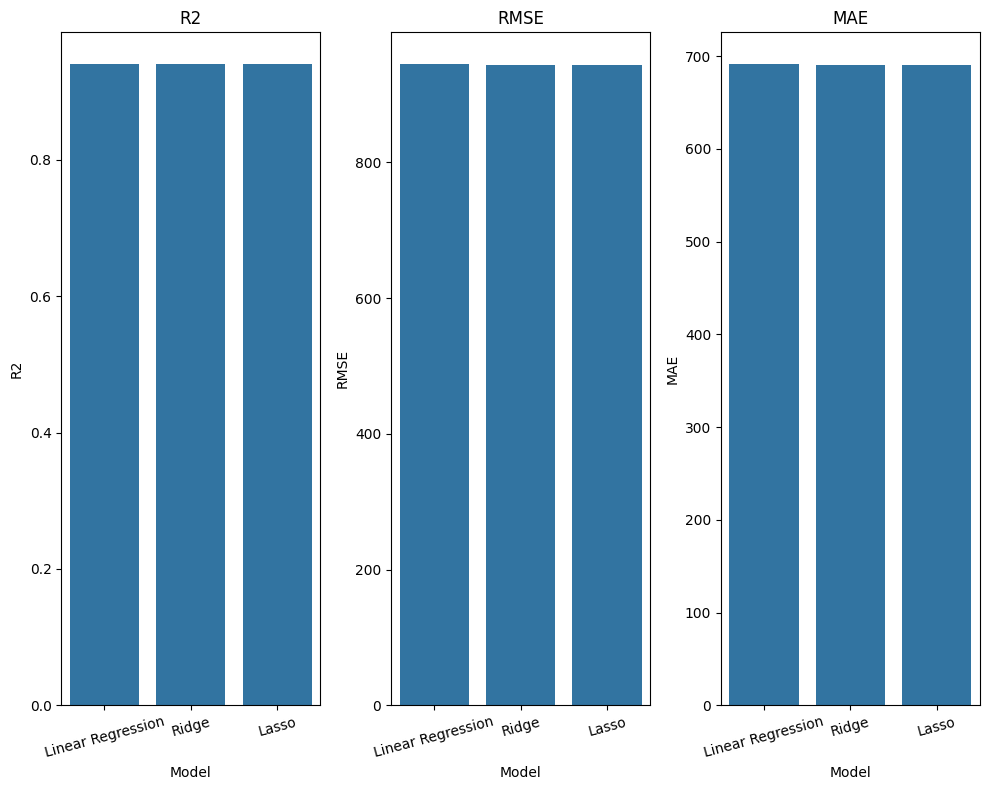

In [113]:
fig , axes = plt.subplots(1,3)
for i,metric in enumerate(['R2' , 'RMSE' , 'MAE']):
    sns.barplot(x='Model' , y=metric , data=results_df , ax=axes[i])
    axes[i].set_title(metric)
    axes[i].tick_params(axis='x' , rotation=15)

plt.tight_layout()
plt.show()

### 6.2 Cross Validation 

In [114]:
from sklearn.model_selection import cross_val_score

cv_results =[]

for name,model in models.items():
    scores = cross_val_score(model , X_train , y_train , cv=5 , scoring='r2')
    cv_results.append({
        'Model' : name,
        'CV Mean R2' : round(scores.mean(),4),
        'CV Std' : round(scores.std() ,4)
    })

cv_df = pd.DataFrame(cv_results)

display(cv_df)

,Model,CV Mean R2,CV Std
0,Linear Regression,0.939,0.0009
1,Ridge,0.939,0.0009
2,Lasso,0.939,0.0009


In [115]:
results_df = results_df.merge(cv_df,on='Model')
results_df

,Model,R2,RMSE,MAE,CV Mean R2,CV Std
0,Linear Regression,0.9402,944.32,691.17,0.939,0.0009
1,Ridge,0.9402,944.12,691.02,0.939,0.0009
2,Lasso,0.9402,943.91,690.81,0.939,0.0009


In [116]:
for _,row in results_df.iterrows():
    diff = abs(row['R2'] - row['CV Mean R2'])
    print(f"{row['Model']:20s} | Test R2 : {row['R2']:.4f} | CV R2 : {row['CV Mean R2']:.4f} | Diff : {diff:.4f}")

Linear Regression    | Test R2 : 0.9402 | CV R2 : 0.9390 | Diff : 0.0012
Ridge                | Test R2 : 0.9402 | CV R2 : 0.9390 | Diff : 0.0012
Lasso                | Test R2 : 0.9402 | CV R2 : 0.9390 | Diff : 0.0012


### 6.3 Hyperparameter Tuning

In [117]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'Ridge' : {'alpha' : [0.01 , 0.1 ,1 ,10 ,100 ,1000]},
    'Lasso' : {'alpha' : [0.01 , 0.1 ,1 ,10 ,100 ,1000]}
}

best_models = {}

for name in ['Ridge' , 'Lasso']:
    grid = GridSearchCV(
        models[name] ,
        param_grid[name] ,
        cv=5 , 
        scoring='r2' , 
        n_jobs=-1 
    )

    grid.fit(X_train,y_train)
    best_models[name] = grid

    print(f"{name} : ")
    print(f"Best alpha : {grid.best_params_['alpha']}")
    print(f"Best CV R2 : {grid.best_score_:.4f}")
    print(f"Test R2 : {r2_score(y_test , grid.predict(X_test)):.4f}")

Ridge : 
Best alpha : 1
Best CV R2 : 0.9390
Test R2 : 0.9402
Lasso : 
Best alpha : 10
Best CV R2 : 0.9392
Test R2 : 0.9404


In [118]:
tuned_results = []

for name in ['Ridge' , 'Lasso']:
    y_pred_tuned = best_models[name].predict(X_test)
    tuned_results.append({
        'Model' : name + 'Tuned',
        'Best Alpha' : best_models[name].best_params_['alpha'],
        'R2' : round(r2_score(y_test,y_pred_tuned),4),
        'RMSE' : round(mean_squared_error(y_test , y_pred_tuned)**0.5,2)
    })

y_pred_lr = models['Linear Regression'].predict(X_test)
tuned_results.append({
    'Model' : 'Linear Regression',
    'Best Alpha' : '-',
    'R2' : round(r2_score(y_test,y_pred_lr),4),
    'RMSE' : round(mean_squared_error(y_test , y_pred_lr)**0.5,2)
})

In [119]:
tuned_df = pd.DataFrame(tuned_results)
tuned_df

,Model,Best Alpha,R2,RMSE
0,RidgeTuned,1,0.9402,944.12
1,LassoTuned,10,0.9404,942.67
2,Linear Regression,-,0.9402,944.32


### 6.4 Model Evaluation Visualizations

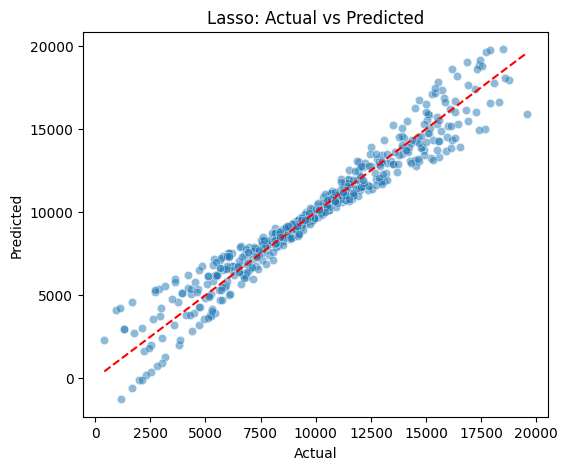

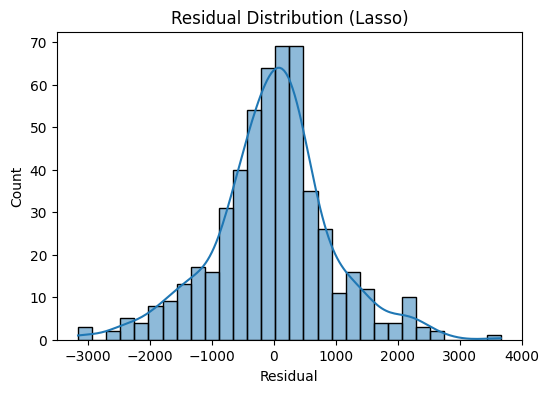

In [120]:
# Use best model (Lasso tuned) for predictions
best = best_models['Lasso']
y_pred_best = best.predict(X_test)
residuals = y_test - y_pred_best

# 1. Actual vs Predicted
plt.figure(figsize=(6,5))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Lasso: Actual vs Predicted')
plt.show()

# 2. Residuals distribution
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel('Residual')
plt.title('Residual Distribution (Lasso)')
plt.show()

C:\Users\Santosh\AppData\Local\Temp\ipykernel_732\1483709878.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coeff_df.head(10), palette=colors )


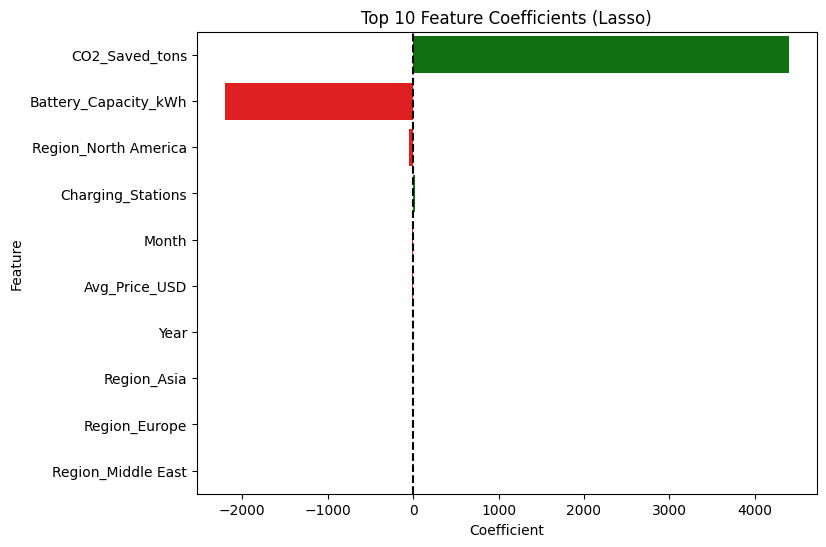

In [121]:
# 3. Coefficients plot
coeffs = best.best_estimator_.coef_
feature_names = all_features if 'all_features' in dir() else X.columns

coeff_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coeffs
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(8,6))
colors = ['green' if c > 0 else 'red' for c in coeff_df['Coefficient'].head(10)]
sns.barplot(x='Coefficient', y='Feature', data=coeff_df.head(10), palette=colors )
plt.title('Top 10 Feature Coefficients (Lasso)')
plt.axvline(0, color='black', linestyle='--')
plt.show()

### 6.5 Saving Models

In [123]:
import os
import joblib

os.makedirs('artifacts', exist_ok=True)

joblib.dump(models['Linear Regression'], 'artifacts/linear_regression_model.pkl')
joblib.dump(models['Ridge'], 'artifacts/ridge_model.pkl')
joblib.dump(best_models['Lasso'].best_estimator_, 'artifacts/lasso_tuned_model.pkl')
joblib.dump(scaler, 'artifacts/scaler.pkl')
joblib.dump(encoder, 'artifacts/encoder.pkl')

print("Models saved in 'artifacts/' folder!")


Models saved in 'artifacts/' folder!


## Part 7 - Conclusion

| Model | R² | RMSE | Best Alpha |
|-------|:---:|:----:|:----------:|
| Linear Regression | 0.9402 | 944.32 | - |
| Ridge | 0.9402 | 944.12 | 1 |
| Lasso | **0.9404** | **942.67** | 10 |

All three models did well with an R² of ~0.94. Lasso (alpha=10) edged out slightly. Models were very stable — CV and test scores were almost identical (diff: 0.0012).

From EDA, deliveries have grown over the years, Production Units and deliveries are strongly linked, and CO2_Saved_tons had the most outliers. Region and Model also play a big role.

Overall, this was a complete ML workflow — from data loading to cleaning, EDA, preprocessing, modeling, and tuning.